In [1]:
# Install required dependencies
!pip install python-igraph numpy matplotlib scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 37.4 MB/s eta 0:00:00


In [2]:
# Basic calculation libraries
import numpy as np
import pandas as pd
from scipy import stats

# Core network analysis library (much more efficient for large networks than networkx)
import igraph as ig

# Visualization library
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# -------------------------- Core Utility Functions --------------------------
def calculate_network_metrics(G: ig.Graph, net_name: str) -> pd.DataFrame:
    """
    Calculate 7 macro network structure metrics as required by the assignment.
    Input: igraph Graph object, network name.
    Output: Metrics DataFrame
    """
    # Process only the Largest Connected Component (standard for path/diameter metrics in disconnected networks)
    if not G.is_connected():
        G_lcc = G.components().giant()
        print(f"{net_name} network is disconnected, path/clustering/diameter metrics are calculated only on the largest connected component.")
    else:
        G_lcc = G.copy()

    # Basic metrics
    n_nodes = G.vcount()  # Number of nodes
    n_edges = G.ecount()  # Number of edges

    # Degree-related metrics
    degrees = G.degree()
    k_min = np.min(degrees)
    k_max = np.max(degrees)
    k_avg = np.mean(degrees)

    # Average Clustering Coefficient (average of node clustering coefficients)
    avg_clustering = G_lcc.transitivity_avglocal_undirected()

    # Degree Assortativity Coefficient
    assortativity = G.assortativity_degree()

    # Average Path Length
    avg_path_length = G_lcc.average_path_length()

    # Network Diameter
    diameter = G_lcc.diameter()

    # Compile results
    metrics_dict = {
        "Metric Name": ["Number of Nodes", "Number of Edges", "Minimum Degree", "Maximum Degree", "Average Degree",
                   "Average Clustering Coefficient", "Degree Assortativity", "Average Path Length", "Network Diameter"],
        net_name: [n_nodes, n_edges, k_min, k_max, round(k_avg, 4),
                  round(avg_clustering, 4), round(assortativity, 4),
                  round(avg_path_length, 4), diameter]
    }
    return pd.DataFrame(metrics_dict)

def log_log_histogram(degrees: list, net_name: str, n_bins: int = 10, plot: bool = True):
    """
    Implements Log-Log Histogram with Logarithmic Binning strictly following the reference document: (PDF+CCDF) + Power-Law exponent fitting.
    Input: List of node degrees, network name, number of bins, plot flag.
    Output: Power-Law exponent γ, binning results, plot object.
    """
    # Filter out zero-degree nodes (logarithm is undefined)
    k = np.array(degrees)
    k = k[k > 0]
    n = len(k)
    if n == 0:
        print(f"{net_name} has no valid degree data")
        return None, None, None

    # -------------------------- Standard Procedure from Reference Document --------------------------
    # Step 1: Find k_min and k_max
    k_min = np.min(k)
    k_max = np.max(k)

    # Step 2: Take logarithm of all k_i (using base 10, can be replaced by np.log for natural logarithm)
    log_k = np.log10(k)

    # Step 3: Divide logarithmic interval into equal-sized bins
    log_min = np.log10(k_min)
    log_max = np.log10(k_max + 1)  # Reference document requirement: x_B = log(k_max+1)
    bins = np.linspace(log_min, log_max, n_bins + 1)

    # Step 4: Count elements in each bin
    counts, bin_edges = np.histogram(log_k, bins=bins)

    # Step 5: Calculate probability PDF for each bin
    p_b = counts / n

    # Calculate bin centers (for plotting and fitting)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Filter empty bins
    valid_idx = counts > 0
    valid_centers = bin_centers[valid_idx]
    valid_p = p_b[valid_idx]
    log_valid_p = np.log10(valid_p)

    # Power-law exponent fitting: Linear regression, absolute value of slope is γ
    if len(valid_centers) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(valid_centers, log_valid_p)
        gamma = -slope
        fit_line = slope * valid_centers + intercept
    else:
        gamma = None
        fit_line = None
        print(f"{net_name} has insufficient valid bins, unable to fit power-law exponent")

    # Calculate CCDF (Complementary Cumulative Distribution Function, as per reference document)
    ccdf = np.cumsum(p_b[::-1])[::-1]

    # -------------------------- Plotting --------------------------
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # PDF Log-Log Plot
        ax1.scatter(valid_centers, log_valid_p, color='navy', s=60, label='Empirical Distribution')
        if fit_line is not None:
            ax1.plot(valid_centers, fit_line, 'r--', linewidth=2, label=f'Fit Line γ={round(gamma, 3)}')
        ax1.set_xlabel('log(k) (log of degree)', fontsize=12)
        ax1.set_ylabel('log(P(k)) (log of probability density)', fontsize=12)
        ax1.set_title(f'{net_name} Logarithmic Binning Log-Log PDF Histogram', fontsize=13)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)

        # CCDF Log-Log Plot
        valid_ccdf = ccdf[valid_idx]
        log_valid_ccdf = np.log10(valid_ccdf)
        ax2.scatter(valid_centers, log_valid_ccdf, color='darkgreen', s=60, label='CCDF Distribution')
        ax2.set_xlabel('log(k) (log of degree)', fontsize=12)
        ax2.set_ylabel('log(P(K≥k)) (log of CCDF)', fontsize=12)
        ax2.set_title(f'{net_name} Complementary Cumulative Distribution CCDF', fontsize=13)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)

        plt.tight_layout()
        plt.savefig(f'{net_name}_degree_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Compile results
    bin_result = pd.DataFrame({
        "Bin Left Boundary (log10)": bin_edges[:-1],
        "Bin Right Boundary (log10)": bin_edges[1:],
        "Bin Center (log10)": bin_centers,
        "Node Count": counts,
        "PDF Probability": p_b,
        "CCDF Probability": ccdf
    })

    return gamma, bin_result, fit_line

def get_top_centrality_nodes(G: ig.Graph, net_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Calculates 3 centrality metrics and outputs Top N core nodes.
    Input: igraph Graph object, network name, number of top nodes.
    Output: Top nodes DataFrame
    """
    # Degree Centrality (normalized)
    degree_centrality = G.degree(normalized=True)
    # Betweenness Centrality (normalized)
    betweenness_centrality = G.betweenness(normalized=True)
    # Eigenvector Centrality
    eigenvector_centrality = G.eigenvector_centrality()

    # Compile top nodes
    top_result = {}
    # Top 5 Degree Centrality
    top_degree = np.argsort(degree_centrality)[::-1][:top_n]
    top_result["Degree Centrality Top Nodes"] = top_degree
    top_result["Degree Centrality Score"] = [round(degree_centrality[i], 6) for i in top_degree]

    # Top 5 Betweenness Centrality
    top_betweenness = np.argsort(betweenness_centrality)[::-1][:top_n]
    top_result["Betweenness Centrality Top Nodes"] = top_betweenness
    top_result["Betweenness Centrality Score"] = [round(betweenness_centrality[i], 6) for i in top_betweenness]

    # Top 5 Eigenvector Centrality
    top_eigen = np.argsort(eigenvector_centrality)[::-1][:top_n]
    top_result["Eigenvector Centrality Top Nodes"] = top_eigen
    top_result["Eigenvector Centrality Score"] = [round(eigenvector_centrality[i], 6) for i in top_eigen]

    print(f"==================== {net_name} Centrality Top {top_n} Nodes ====================")
    result_df = pd.DataFrame(top_result)
    print(result_df)
    return result_df

def small_world_judge(G: ig.Graph) -> tuple[float, float, str]:
    """
    Small-world network judgment: Compare against an ER random network of the same size and average degree.
    Output: Clustering coefficient ratio, path length ratio, judgment result.
    """
    if not G.is_connected():
        G = G.components().giant()

    # Original network metrics
    n = G.vcount()
    m = G.ecount()
    avg_k = 2 * m / n
    C_original = G.transitivity_avglocal_undirected()
    L_original = G.average_path_length()

    # Generate 100 ER networks of the same size and average their values to reduce random error
    C_er_list = []
    L_er_list = []
    for _ in range(100):
        G_er = ig.Graph.Erdos_Renyi(n=n, m=m)
        if not G_er.is_connected():
            G_er = G_er.components().giant()
        C_er_list.append(G_er.transitivity_avglocal_undirected())
        L_er_list.append(G_er.average_path_length())

    C_er = np.mean(C_er_list)
    L_er = np.mean(L_er_list)

    # Small-world judgment criteria: C >> C_er and L ≈ L_er
    C_ratio = C_original / C_er
    L_ratio = L_original / L_er

    if C_ratio > 2 and L_ratio < 1.5:
        judge = "Exhibits small-world network properties"
    else:
        judge = "Does not exhibit small-world network properties"

    return round(C_ratio, 3), round(L_ratio, 3), judge



==================== Starting Analysis for net1 ====================

net1 Macro Structure Metrics:
                           Metric        net1
0                 Number of Nodes   5000.0000
1                 Number of Edges  25000.0000
2                  Minimum Degree      6.0000
3                  Maximum Degree     16.0000
4                  Average Degree     10.0000
5  Average Clustering Coefficient      0.4141
6            Degree Assortativity     -0.0097
7             Average Path Length      5.1211
8                Network Diameter      8.0000


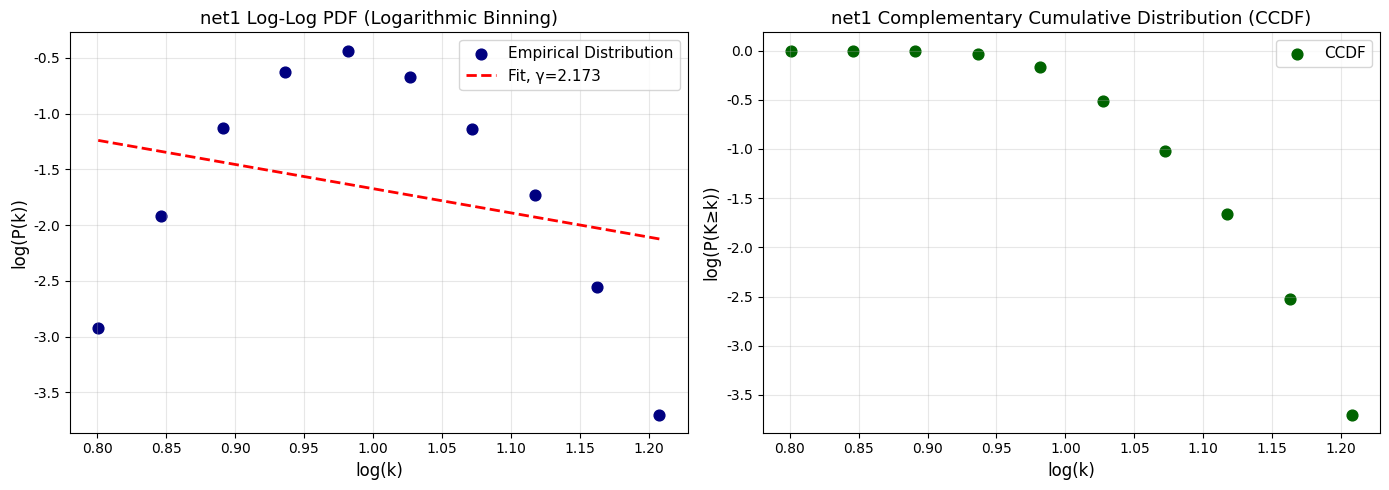


net1 Estimated Power-Law Exponent γ = 2.173
==================== net1 Top 5 Central Nodes ====================
   Degree_Centrality_Nodes  Degree_Centrality_Score  \
0                     1693                 0.003201   
1                     1579                 0.003001   
2                     4891                 0.003001   
3                      651                 0.003001   
4                       41                 0.002801   

   Betweenness_Centrality_Nodes  Betweenness_Centrality_Score  \
0                          4747                      0.004055   
1                          2645                      0.004047   
2                           230                      0.003803   
3                          4360                      0.003795   
4                          1579                      0.003655   

   Eigenvector_Centrality_Nodes  Eigenvector_Centrality_Score  
0                           651                      1.000000  
1                          1937       

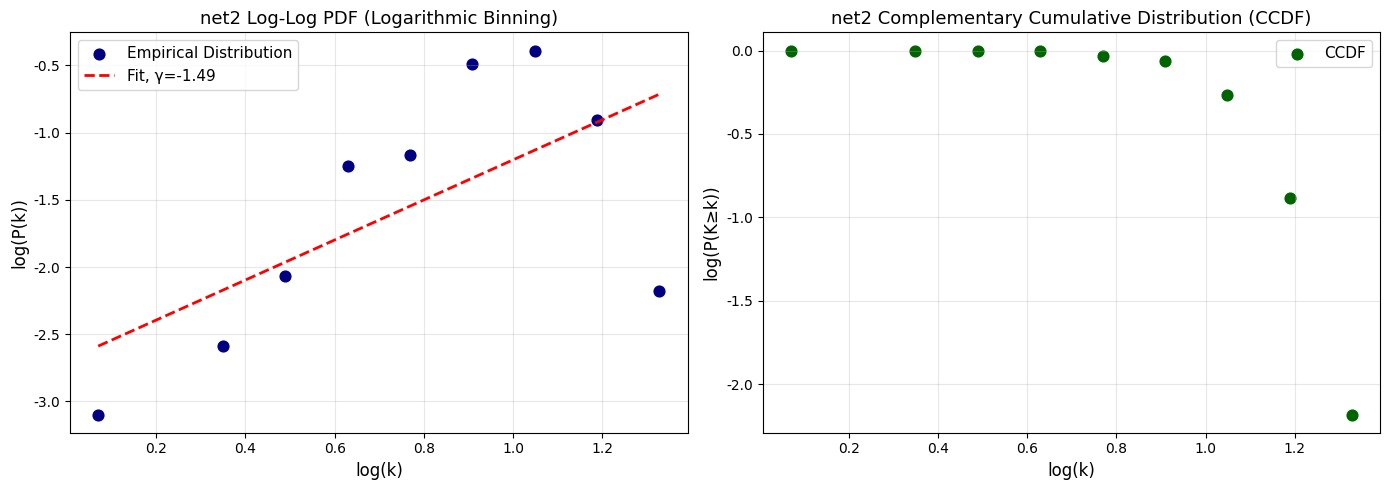


net2 Estimated Power-Law Exponent γ = -1.49
==================== net2 Top 5 Central Nodes ====================
   Degree_Centrality_Nodes  Degree_Centrality_Score  \
0                     1581                 0.004801   
1                      787                 0.004601   
2                       52                 0.004201   
3                     2372                 0.004201   
4                     1990                 0.004201   

   Betweenness_Centrality_Nodes  Betweenness_Centrality_Score  \
0                          1581                      0.003302   
1                           787                      0.002559   
2                          4382                      0.002464   
3                            52                      0.002274   
4                          2375                      0.002269   

   Eigenvector_Centrality_Nodes  Eigenvector_Centrality_Score  
0                          1581                      1.000000  
1                          3233       

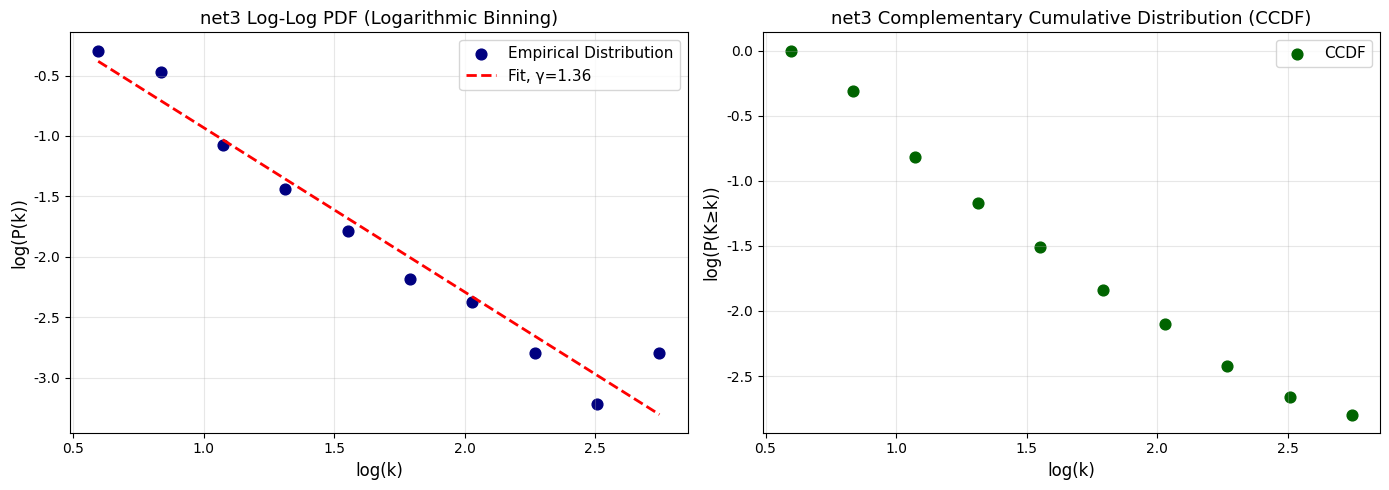


net3 Estimated Power-Law Exponent γ = 1.36
==================== net3 Top 5 Central Nodes ====================
   Degree_Centrality_Nodes  Degree_Centrality_Score  \
0                        5                 0.146429   
1                        7                 0.138228   
2                        2                 0.125225   
3                        0                 0.124025   
4                        6                 0.111022   

   Betweenness_Centrality_Nodes  Betweenness_Centrality_Score  \
0                             5                      0.137808   
1                             7                      0.127671   
2                             0                      0.111343   
3                             2                      0.109299   
4                             6                      0.094286   

   Eigenvector_Centrality_Nodes  Eigenvector_Centrality_Score  
0                             5                      1.000000  
1                             7        

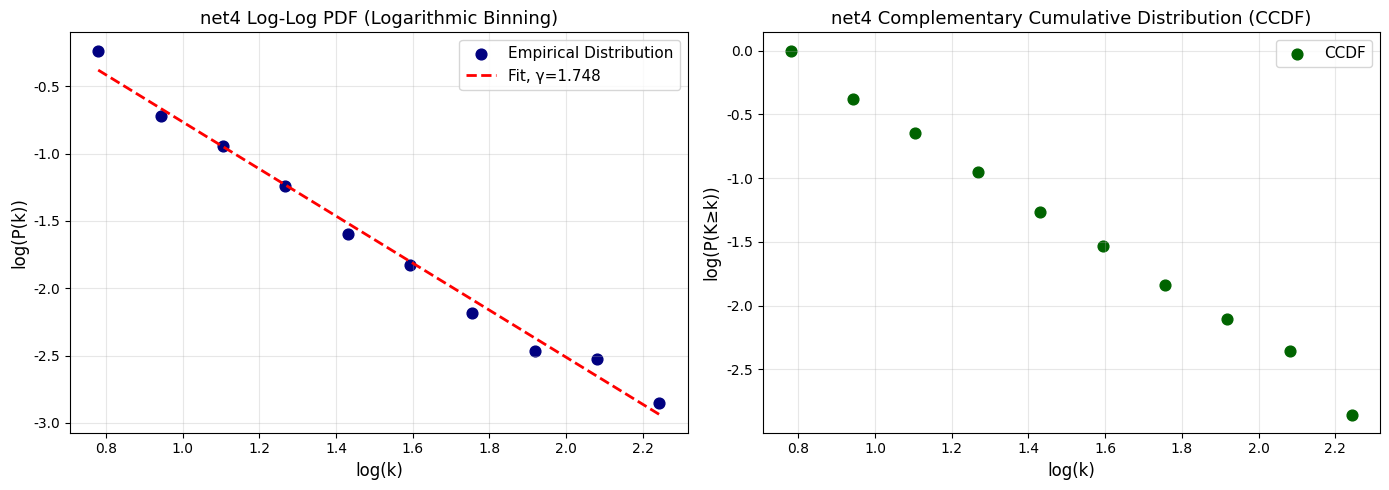


net4 Estimated Power-Law Exponent γ = 1.748
==================== net4 Top 5 Central Nodes ====================
   Degree_Centrality_Nodes  Degree_Centrality_Score  \
0                        6                 0.042008   
1                        0                 0.041208   
2                        9                 0.040808   
3                       10                 0.032607   
4                        8                 0.032406   

   Betweenness_Centrality_Nodes  Betweenness_Centrality_Score  \
0                             0                      0.060500   
1                             6                      0.057592   
2                             9                      0.055262   
3                             8                      0.039073   
4                             3                      0.037926   

   Eigenvector_Centrality_Nodes  Eigenvector_Centrality_Score  
0                             6                      1.000000  
1                             0       

In [3]:
# -------------------------- Configuration (Modify paths to your files) --------------------------
# Network file paths, supports Pajek (.net), edgelist, gml, etc.
net_file_paths = {
    "net1": "/content/drive/MyDrive/activityA1/net1.net",
    "net2": "/content/drive/MyDrive/activityA1/net2.net",
    "net3": "/content/drive/MyDrive/activityA1/net3.net",
    "net4": "/content/drive/MyDrive/activityA1/net4.net"
}
# Number of logarithmic bins (adjust based on data size)
log_bins_num = 10
# Number of top nodes for centrality analysis
top_n = 5

# -------------------------- Core Libraries & Utility Functions --------------------------
import numpy as np
import pandas as pd
from scipy import stats
import igraph as ig
import matplotlib.pyplot as plt

# Configure plotting for English environment (no font warnings)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def calculate_network_metrics(G: ig.Graph, net_name: str) -> pd.DataFrame:
    """
    Calculate 7 core macro network structure metrics as required by the assignment.
    Input: igraph Graph object, network name
    Output: Metrics DataFrame
    """
    # Process only the Largest Connected Component (LCC) if disconnected
    if not G.is_connected():
        G_lcc = G.components().giant()
        print(f"{net_name} is disconnected. Metrics for Path/Clustering/Diameter are calculated on LCC.")
    else:
        G_lcc = G.copy()

    # Basic metrics
    n_nodes = G.vcount()
    n_edges = G.ecount()

    # Degree metrics
    degrees = G.degree()
    k_min = np.min(degrees)
    k_max = np.max(degrees)
    k_avg = np.mean(degrees)

    # Average Clustering Coefficient (average of local clustering coefficients)
    avg_clustering = G_lcc.transitivity_avglocal_undirected()

    # Degree Assortativity
    assortativity = G.assortativity_degree()

    # Average Path Length
    avg_path_length = G_lcc.average_path_length()

    # Network Diameter
    diameter = G_lcc.diameter()

    # Compile results
    metrics_dict = {
        "Metric": ["Number of Nodes", "Number of Edges", "Minimum Degree", "Maximum Degree", "Average Degree",
                   "Average Clustering Coefficient", "Degree Assortativity", "Average Path Length", "Network Diameter"],
        net_name: [n_nodes, n_edges, k_min, k_max, round(k_avg, 4),
                  round(avg_clustering, 4), round(assortativity, 4),
                  round(avg_path_length, 4), diameter]
    }
    return pd.DataFrame(metrics_dict)

def log_log_histogram(degrees: list, net_name: str, n_bins: int = 10, plot: bool = True):
    """
    Implements Log-Log Histogram with Logarithmic Binning strictly following the reference document.
    Calculates PDF, CCDF, and fits Power-Law exponent Gamma.
    Input: List of degrees, network name, number of bins, plot flag
    Output: Gamma, binning results, fit line
    """
    # Filter out zero-degree nodes (logarithm is undefined)
    k = np.array(degrees)
    k = k[k > 0]
    n = len(k)
    if n == 0:
        print(f"{net_name} has no valid degree data.")
        return None, None, None

    # -------------------------- Standard Procedure from Reference Document --------------------------
    # Step 1: Find k_min and k_max
    k_min = np.min(k)
    k_max = np.max(k)

    # Step 2: Take logarithm of all k_i (using base 10, consistent with reference)
    log_k = np.log10(k)

    # Step 3: Divide logarithmic interval into equal-sized bins
    log_min = np.log10(k_min)
    log_max = np.log10(k_max + 1)  # Reference document requirement: x_B = log(k_max+1)
    bins = np.linspace(log_min, log_max, n_bins + 1)

    # Step 4: Count elements in each bin
    counts, bin_edges = np.histogram(log_k, bins=bins)

    # Step 5: Calculate probability PDF for each bin
    p_b = counts / n

    # Calculate bin centers (for plotting and fitting)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Filter empty bins
    valid_idx = counts > 0
    valid_centers = bin_centers[valid_idx]
    valid_p = p_b[valid_idx]
    log_valid_p = np.log10(valid_p)

    # Power-law exponent fitting: Linear regression, absolute value of slope is Gamma
    gamma = None
    fit_line = None
    if len(valid_centers) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(valid_centers, log_valid_p)
        gamma = -slope
        fit_line = slope * valid_centers + intercept

    # Calculate CCDF (Complementary Cumulative Distribution Function)
    ccdf = np.cumsum(p_b[::-1])[::-1]

    # -------------------------- Plotting --------------------------
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # PDF Log-Log Plot
        ax1.scatter(valid_centers, log_valid_p, color='navy', s=60, label='Empirical Distribution')
        if fit_line is not None:
            ax1.plot(valid_centers, fit_line, 'r--', linewidth=2, label=f'Fit, γ={round(gamma, 3)}')
        ax1.set_xlabel('log(k)', fontsize=12)
        ax1.set_ylabel('log(P(k))', fontsize=12)
        ax1.set_title(f'{net_name} Log-Log PDF (Logarithmic Binning)', fontsize=13)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)

        # CCDF Log-Log Plot
        valid_ccdf = ccdf[valid_idx]
        log_valid_ccdf = np.log10(valid_ccdf)
        ax2.scatter(valid_centers, log_valid_ccdf, color='darkgreen', s=60, label='CCDF')
        ax2.set_xlabel('log(k)', fontsize=12)
        ax2.set_ylabel('log(P(K≥k))', fontsize=12)
        ax2.set_title(f'{net_name} Complementary Cumulative Distribution (CCDF)', fontsize=13)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)

        plt.tight_layout()
        plt.savefig(f'{net_name}_degree_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Compile binning results
    bin_result = pd.DataFrame({
        "Bin_Left_log10": bin_edges[:-1],
        "Bin_Right_log10": bin_edges[1:],
        "Bin_Center_log10": bin_centers,
        "Node_Count": counts,
        "PDF_Probability": p_b,
        "CCDF_Probability": ccdf
    })

    return gamma, bin_result, fit_line

def get_top_centrality_nodes(G: ig.Graph, net_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Calculates 3 centrality metrics and outputs Top N nodes.
    Compatible with older versions of igraph.
    Input: igraph Graph object, network name, number of top nodes
    Output: Top nodes DataFrame
    """
    n = G.vcount()

    # 1. Degree Centrality (Manual normalization for compatibility)
    degree_raw = G.degree()
    degree_centrality = [d / (n - 1) for d in degree_raw]

    # 2. Betweenness Centrality (Manual normalization for compatibility)
    betweenness_raw = G.betweenness()
    if n > 2:
        norm_factor = 2 / ((n - 1) * (n - 2)) # Normalization factor for undirected graphs
    else:
        norm_factor = 1
    betweenness_centrality = [b * norm_factor for b in betweenness_raw]

    # 3. Eigenvector Centrality (Compatibility wrapper)
    try:
        eigenvector_centrality = G.eigenvector_centrality()
    except:
        eigenvector_centrality = G.evcent()

    # Compile Top N results
    top_result = {}

    # Top Degree
    top_degree = np.argsort(degree_centrality)[::-1][:top_n]
    top_result["Degree_Centrality_Nodes"] = top_degree
    top_result["Degree_Centrality_Score"] = [round(degree_centrality[i], 6) for i in top_degree]

    # Top Betweenness
    top_betweenness = np.argsort(betweenness_centrality)[::-1][:top_n]
    top_result["Betweenness_Centrality_Nodes"] = top_betweenness
    top_result["Betweenness_Centrality_Score"] = [round(betweenness_centrality[i], 6) for i in top_betweenness]

    # Top Eigenvector
    top_eigen = np.argsort(eigenvector_centrality)[::-1][:top_n]
    top_result["Eigenvector_Centrality_Nodes"] = top_eigen
    top_result["Eigenvector_Centrality_Score"] = [round(eigenvector_centrality[i], 6) for i in top_eigen]

    print(f"==================== {net_name} Top {top_n} Central Nodes ====================")
    result_df = pd.DataFrame(top_result)
    print(result_df)
    return result_df

# -------------------------- Batch Analysis Execution --------------------------
# Result storage containers
all_metrics = []
all_gamma = {}
all_centrality = {}
all_bin_results = {}

for net_name, file_path in net_file_paths.items():
    print(f"\n\n==================== Starting Analysis for {net_name} ====================")

    # 1. Load Network (Undirected by default, set directed=True if needed)
    try:
        G = ig.Graph.Read_Pajek(file_path)
        # For GML format use: G = ig.Graph.Read_GML(file_path)
        # For Adjacency list use: G = ig.Graph.Read_Adjacency(file_path)
    except Exception as e:
        print(f"Failed to load {net_name}. Please check path and format! Error: {e}")
        continue

    # 2. Calculate Macro Structure Metrics
    metrics_df = calculate_network_metrics(G, net_name)
    all_metrics.append(metrics_df)
    print(f"\n{net_name} Macro Structure Metrics:")
    print(metrics_df)

    # 3. Degree Distribution Analysis (Log-Log Histogram + Power-Law Fit)
    degrees = G.degree()
    gamma, bin_result, fit_line = log_log_histogram(degrees, net_name, n_bins=log_bins_num)
    all_gamma[net_name] = gamma
    all_bin_results[net_name] = bin_result
    if gamma is not None:
        print(f"\n{net_name} Estimated Power-Law Exponent γ = {round(gamma, 3)}")

    # 4. Centrality Analysis and Top 5 Nodes
    centrality_df = get_top_centrality_nodes(G, net_name, top_n=top_n)
    all_centrality[net_name] = centrality_df

# -------------------------- Merge All Network Metrics for Report --------------------------
final_metrics_df = pd.concat(all_metrics, axis=1)
final_metrics_df = final_metrics_df.loc[:, ~final_metrics_df.columns.duplicated()]
print("\n\n==================== Summary of All Network Metrics ====================")
print(final_metrics_df)

# -------------------------- Export Results to Excel --------------------------
with pd.ExcelWriter('network_analysis_results.xlsx') as writer:
    final_metrics_df.to_excel(writer, sheet_name='Macro_Metrics_Summary', index=False)
    for net_name, df in all_centrality.items():
        df.to_excel(writer, sheet_name=f'{net_name}_Centrality_Top_Nodes', index=False)
    for net_name, df in all_bin_results.items():
        df.to_excel(writer, sheet_name=f'{net_name}_Degree_Dist_Bins', index=False)
    pd.DataFrame.from_dict(all_gamma, orient='index', columns=['Power_Law_Exponent_Gamma']).to_excel(writer, sheet_name='Power_Law_Exponents')

print("\nAnalysis complete! Results saved to network_analysis_results.xlsx, and degree distribution plots saved to current directory.")

Loading net5...
Successfully loaded net5: 200 nodes, 465 edges


==================== net5 Core Feature Analysis ====================
Is Network Connected: False
Number of Components: 7
Total Nodes: 200, Nodes in Largest Component: 125, Percentage: 62.5%


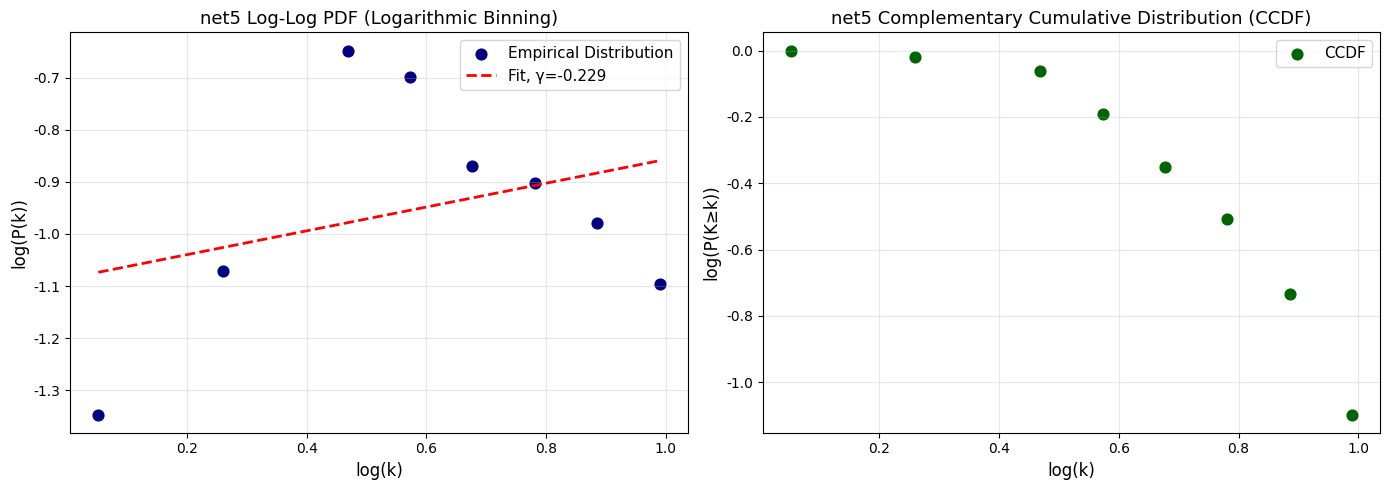


net5 Estimated Power-Law Exponent γ = -0.229
net5 degree distribution does not follow a typical scale-free power law.

net5 Largest Component: Clustering Coefficient / ER Clustering Coefficient = 16.025
net5 Largest Component: Avg Path Length / ER Avg Path Length = 3.891
Small-World Judgment: Does Not Exhibit Small-World Property

Generating network visualization...
Visualization saved to net5_visualization.png

net5 analysis complete! Results saved to net5_analysis_results.xlsx, visualization saved to current directory.


In [6]:
# -------------------------- Configuration (Modify paths to your files) --------------------------
net5_file_path = "/content/drive/MyDrive/activityA1/net5.net"
position_file_path = "/content/drive/MyDrive/activityA1/positions_net5.txt"
log_bins_num = 10

# -------------------------- Core Libraries & Reusable Functions --------------------------
import numpy as np
import pandas as pd
from scipy import stats
import igraph as ig
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def read_network_robust(file_path, directed=False):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    edges = []
    for line in lines:
        line = line.strip()
        if not line or line[0] in ['*', '#', '/', '%']:
            continue
        parts = line.split()
        if len(parts) >= 2:
            try:
                u = int(float(parts[0]))
                v = int(float(parts[1]))
                edges.append((u, v))
            except:
                continue
    if not edges:
        raise ValueError(f"{file_path} No valid edge data found")
    G = ig.Graph.TupleList(edges, directed=directed)
    return G

def log_log_histogram(degrees: list, net_name: str, n_bins: int = 10, plot: bool = True):
    k = np.array(degrees)
    k = k[k > 0]
    n = len(k)
    if n == 0:
        return None, None, None

    k_min = np.min(k)
    k_max = np.max(k)
    log_k = np.log10(k)
    log_min = np.log10(k_min)
    log_max = np.log10(k_max + 1)
    bins = np.linspace(log_min, log_max, n_bins + 1)
    counts, bin_edges = np.histogram(log_k, bins=bins)
    p_b = counts / n
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    valid_idx = counts > 0
    valid_centers = bin_centers[valid_idx]
    valid_p = p_b[valid_idx]
    log_valid_p = np.log10(valid_p)

    gamma = None
    fit_line = None
    if len(valid_centers) >= 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(valid_centers, log_valid_p)
        gamma = -slope
        fit_line = slope * valid_centers + intercept

    ccdf = np.cumsum(p_b[::-1])[::-1]

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.scatter(valid_centers, log_valid_p, color='navy', s=60, label='Empirical Distribution')
        if fit_line is not None:
            ax1.plot(valid_centers, fit_line, 'r--', linewidth=2, label=f'Fit, γ={round(gamma, 3)}')
        ax1.set_xlabel('log(k)', fontsize=12)
        ax1.set_ylabel('log(P(k))', fontsize=12)
        ax1.set_title(f'{net_name} Log-Log PDF (Logarithmic Binning)', fontsize=13)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)

        valid_ccdf = ccdf[valid_idx]
        log_valid_ccdf = np.log10(valid_ccdf)
        ax2.scatter(valid_centers, log_valid_ccdf, color='darkgreen', s=60, label='CCDF')
        ax2.set_xlabel('log(k)', fontsize=12)
        ax2.set_ylabel('log(P(K≥k))', fontsize=12)
        ax2.set_title(f'{net_name} Complementary Cumulative Distribution (CCDF)', fontsize=13)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)

        plt.tight_layout()
        plt.savefig(f'{net_name}_degree_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

    bin_result = pd.DataFrame({
        "Bin_Left_log10": bin_edges[:-1],
        "Bin_Right_log10": bin_edges[1:],
        "Bin_Center_log10": bin_centers,
        "Node_Count": counts,
        "PDF_Probability": p_b,
        "CCDF_Probability": ccdf
    })
    return gamma, bin_result, fit_line

def small_world_judge(G: ig.Graph) -> tuple[float, float, str]:
    if not G.is_connected():
        G = G.components().giant()

    n = G.vcount()
    m = G.ecount()
    C_original = G.transitivity_avglocal_undirected()
    L_original = G.average_path_length()

    C_er_list = []
    L_er_list = []
    for _ in range(100):
        G_er = ig.Graph.Erdos_Renyi(n=n, m=m)
        if not G_er.is_connected():
            G_er = G_er.components().giant()
        C_er_list.append(G_er.transitivity_avglocal_undirected())
        L_er_list.append(G_er.average_path_length())

    C_er = np.mean(C_er_list)
    L_er = np.mean(L_er_list)

    C_ratio = C_original / C_er
    L_ratio = L_original / L_er

    if C_ratio > 2 and L_ratio < 1.5:
        judge = "Exhibits Small-World Property"
    else:
        judge = "Does Not Exhibit Small-World Property"

    return round(C_ratio, 3), round(L_ratio, 3), judge

# -------------------------- 1. Load Network and Position Data --------------------------
print("Loading net5...")
try:
    G5 = ig.Graph.Read_Pajek(net5_file_path)
except:
    G5 = read_network_robust(net5_file_path, directed=False)
print(f"Successfully loaded net5: {G5.vcount()} nodes, {G5.ecount()} edges")

# -------------------------- [KEY FIX] Read position file (SKIP HEADER ROW) --------------------------
# Use skiprows=1 to ignore the first line (header like "Node", "x", "y")
positions = np.loadtxt(position_file_path, skiprows=1)

# Ensure position order matches node IDs
# If positions.txt has NO NodeID column (just x y), use: layout = ig.Layout(positions.tolist())
layout = ig.Layout(positions[:, 1:].tolist())

# -------------------------- 2. Core Feature Analysis --------------------------
print("\n\n==================== net5 Core Feature Analysis ====================")
# 2.1 Connectivity Check
is_connected = G5.is_connected()
# [FIX 1] Use len() instead of .count()
n_components = len(G5.components())
lcc_size = G5.components().giant().vcount()
total_nodes = G5.vcount()
print(f"Is Network Connected: {is_connected}")
print(f"Number of Components: {n_components}")
print(f"Total Nodes: {total_nodes}, Nodes in Largest Component: {lcc_size}, Percentage: {round(lcc_size/total_nodes*100, 2)}%")

# 2.2 Scale-Free Property Check
degrees5 = G5.degree()
gamma5, bin_result5, fit_line5 = log_log_histogram(degrees5, "net5", n_bins=log_bins_num)
if gamma5 is not None:
    print(f"\nnet5 Estimated Power-Law Exponent γ = {round(gamma5, 3)}")
    if 2 < gamma5 < 3.5:
        print("net5 degree distribution follows a power law, exhibits scale-free property.")
    else:
        print("net5 degree distribution does not follow a typical scale-free power law.")
else:
    print("net5 cannot fit power-law exponent, no scale-free property.")

# 2.3 Small-World Property Check
C_ratio, L_ratio, sw_judge = small_world_judge(G5)
print(f"\nnet5 Largest Component: Clustering Coefficient / ER Clustering Coefficient = {C_ratio}")
print(f"net5 Largest Component: Avg Path Length / ER Avg Path Length = {L_ratio}")
print(f"Small-World Judgment: {sw_judge}")

# -------------------------- 3. Network Visualization (FIXED 2) --------------------------
# [FIX 2] Avoid matplotlib ax backend conflict by using igraph's direct plot/save
print("\nGenerating network visualization...")
ig.plot(
    G5,
    'net5_visualization.png',       # Save directly to file
    layout=layout,
    vertex_size=8,
    vertex_color='steelblue',
    edge_color='gray',
    edge_width=0.5,
    vertex_frame_width=0.3,
    vertex_frame_color='white',
    bbox=(800, 800),                # Image size
    margin=50
)
print("Visualization saved to net5_visualization.png")

# -------------------------- Export net5 Results --------------------------
with pd.ExcelWriter('net5_analysis_results.xlsx') as writer:
    bin_result5.to_excel(writer, sheet_name='Degree_Distribution_Bins', index=False)
    pd.DataFrame({
        "Metric": ["Is Connected", "Number of Components", "Total Nodes", "Nodes in LCC", "Power-Law Exponent γ", "Clustering Ratio (vs ER)", "Path Length Ratio (vs ER)", "Small-World Judgment"],
        "Value": [is_connected, n_components, total_nodes, lcc_size, gamma5, C_ratio, L_ratio, sw_judge]
    }).to_excel(writer, sheet_name='Core_Features_Summary', index=False)

print("\nnet5 analysis complete! Results saved to net5_analysis_results.xlsx, visualization saved to current directory.")